# Cross-setup LPB evaluation

Visualize LPB coverage and bound size when the survival model is trained on one setup and calibration/test data come from another setup over the same base dataset.

In [1]:
from pathlib import Path
import sys
import textwrap

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display


PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "src").exists() and (PROJECT_ROOT.parent / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

DATASET_NAME = "dataset_toxicity"
DATASET_SETUP = "attack_toxic_attack_qwen25_14b_instruct_lm_target_qwen25_14b_instruct_judge_detoxify"

config = {
    
#     "dataset_name": "dataset_red_team",
#     "model_dataset_setup": "attack_default_attack_qwen25_14b_instruct_lm_target_qwen25_14b_instruct_judge_llm-judge_qwen25_14b_instruct",
    
    "dataset_name": "dataset_toxicity",
    "model_dataset_setup": "attack_toxic_attack_qwen25_14b_instruct_lm_target_qwen25_14b_instruct_judge_detoxify",
    "evaluation_dataset_setup": "attack_toxic_attack_qwen25_14b_instruct_lm_target_gemma3_4b_it_judge_detoxify",
    "budget_per_sample": 20.0,
    "cal_size": 3000,
    "tau_prior": 0.56,
    "gamma": 10.0,
}

experiment_name = (
    "cross_setup_dataset_toxicity_model-cac326ec68_eval-c977e70d22_"
    "budget-20_cal-3000_tau-0.56_gamma-10"
)
csv_path = (
    PROJECT_ROOT
    / "results"
    / "merged_calibration_dfs"
    / experiment_name
    / "all_df.csv"
)
csv_path



PRIMARY_TARGET_COVERAGE = 0.9
DAPRO_CALIBRATION_NAME = "calibration_projected_optimization_platt_prob_allocation"
SAME_SETUP_RESULTS_DIRNAME = (
    "dataset_toxicity_attack_toxic_attack_qwen25_14b_instruct_"
    "lm_target_qwen25_14b_instruct_judge_detoxify_20.0_3000_0.56_10.0"
)


In [2]:
if not csv_path.exists():
    raise FileNotFoundError(
        f"Merged cross-setup LPB results were not found at {csv_path}. "
        "Run src/predictive_bounds/experiments/cross_setup/scripts/run.sh first."
    )

all_df = pd.read_csv(csv_path)
required_columns = {
    "seed",
    "calibration_name",
    "target_coverage",
    "coverage",
    "size",
    "dataset_name",
    "model_dataset_setup",
    "evaluation_dataset_setup",
}
missing_columns = required_columns.difference(all_df.columns)
if missing_columns:
    raise KeyError(f"Missing required columns: {sorted(missing_columns)}")

expected_metadata = {
    "dataset_name": config["dataset_name"],
    "model_dataset_setup": config["model_dataset_setup"],
    "evaluation_dataset_setup": config["evaluation_dataset_setup"],
}
for column, expected_value in expected_metadata.items():
    observed_values = set(all_df[column].dropna().unique())
    if observed_values != {expected_value}:
        raise ValueError(
            f"Unexpected {column}: expected {expected_value!r}, observed {sorted(observed_values)!r}"
        )

display_names = {
    "uncalibrated": "Uncalibrated",
    "oracle_survival_calibration": "Oracle calibration",
    "calibration_optimized_allocation": "Static allocation",
    "calibration_adaptive_optimized_allocation": "Locally adaptive",
    "calibration_projected_optimization_platt_prob_allocation": "DAPRO",
}
plot_df = all_df.loc[all_df["calibration_name"].isin(display_names)].copy()
plot_df["Method"] = plot_df["calibration_name"].map(display_names)
plot_df["Target coverage (%)"] = 100 * plot_df["target_coverage"]
plot_df["Coverage (%)"] = 100 * plot_df["coverage"]

method_order = [name for name in display_names.values() if name in set(plot_df["Method"])]
if not method_order:
    raise ValueError(
        f"None of the requested methods are present. Available: {sorted(all_df['calibration_name'].unique())}"
    )

print(f"Loaded {plot_df['seed'].nunique()} seeds and {len(method_order)} methods.")
plot_df.groupby("Method")["seed"].nunique().reindex(method_order).rename("number_of_seeds")


Loaded 50 seeds and 5 methods.


Method
Uncalibrated          50
Oracle calibration    50
Static allocation     50
Locally adaptive      50
DAPRO                 50
Name: number_of_seeds, dtype: int64

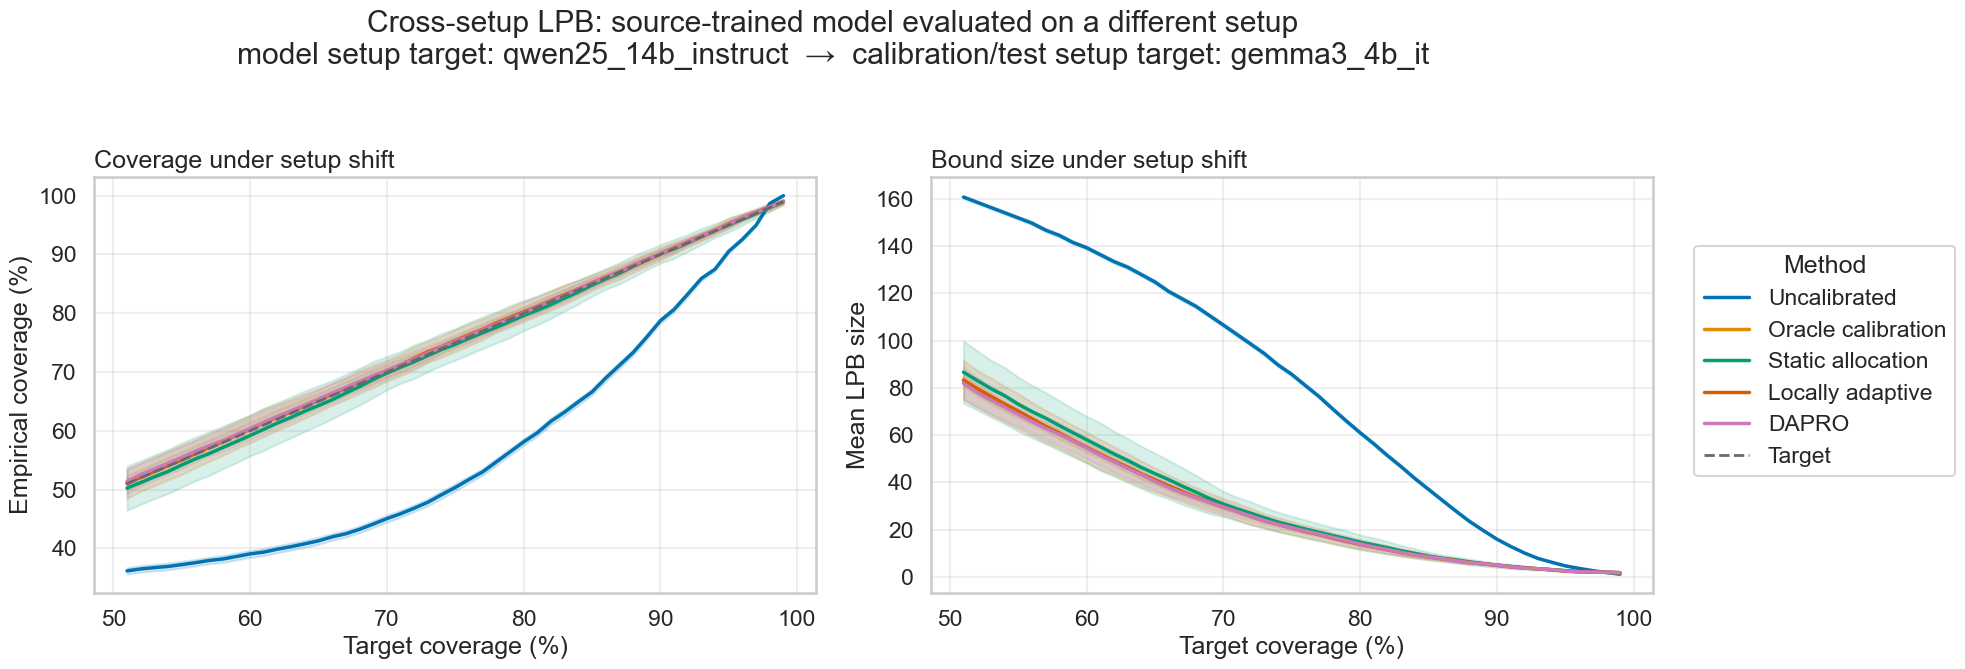

Saved figure to C:\Users\Shai1\Documents\projects\dapro_rebuttal\notebooks\figures\cross_setup\cross_setup_dataset_toxicity_model-cac326ec68_eval-c977e70d22_budget-20_cal-3000_tau-0.56_gamma-10\cross_setup_lpb_coverage_and_size.png


In [3]:
sns.set_theme(style="whitegrid", context="talk")
palette = dict(zip(method_order, sns.color_palette("colorblind", len(method_order))))

fig, axes = plt.subplots(1, 2, figsize=(17, 6.5), sharex=True)

for method in method_order:
    method_df = plot_df.loc[plot_df["Method"].eq(method)]
    stats = method_df.groupby("Target coverage (%)", as_index=False).agg(
        coverage_mean=("Coverage (%)", "mean"),
        coverage_std=("Coverage (%)", "std"),
        size_mean=("size", "mean"),
        size_std=("size", "std"),
    ).fillna(0)
    x = stats["Target coverage (%)"].to_numpy()
    coverage_mean = stats["coverage_mean"].to_numpy()
    coverage_std = stats["coverage_std"].to_numpy()
    size_mean = stats["size_mean"].to_numpy()
    size_std = stats["size_std"].to_numpy()
    color = palette[method]

    axes[0].plot(x, coverage_mean, label=method, color=color, linewidth=2.5)
    axes[0].fill_between(
        x,
        coverage_mean - coverage_std,
        coverage_mean + coverage_std,
        color=color,
        alpha=0.15,
    )
    axes[1].plot(x, size_mean, label=method, color=color, linewidth=2.5)
    axes[1].fill_between(
        x,
        size_mean - size_std,
        size_mean + size_std,
        color=color,
        alpha=0.15,
    )

coverage_range = np.sort(plot_df["Target coverage (%)"].unique())
axes[0].plot(
    coverage_range,
    coverage_range,
    color="dimgray",
    linestyle="--",
    linewidth=2,
    label="Target",
)

axes[0].set_ylabel("Empirical coverage (%)")
axes[0].set_title("Coverage under setup shift", loc="left")
axes[1].set_ylabel("Mean LPB size")
axes[1].set_title("Bound size under setup shift", loc="left")
for ax in axes:
    ax.set_xlabel("Target coverage (%)")
    ax.grid(True, alpha=0.3)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="center left",
    bbox_to_anchor=(1.0, 0.5),
    title="Method",
    frameon=True,
)
def target_model_label(setup):
    marker = "_lm_target_"
    if marker in setup and "_judge_" in setup:
        return setup.split(marker, 1)[1].split("_judge_", 1)[0]
    return textwrap.shorten(setup, width=42, placeholder="…")

source_label = target_model_label(config["model_dataset_setup"])
evaluation_label = target_model_label(config["evaluation_dataset_setup"])
fig.suptitle(
    "Cross-setup LPB: source-trained model evaluated on a different setup\n"
    f"model setup target: {source_label}  →  calibration/test setup target: {evaluation_label}",
    y=1.04,
)

figure_dir = PROJECT_ROOT / "notebooks" / "figures" / "cross_setup" / experiment_name
figure_dir.mkdir(parents=True, exist_ok=True)
figure_path = figure_dir / "cross_setup_lpb_coverage_and_size.png"
fig.tight_layout()
fig.savefig(figure_path, dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved figure to {figure_path}")


## DAPRO: same-model versus train-setup shift

This comparison isolates a shift between the data used to train the survival
model and the distribution used for calibration/test:

- **No train shift:** Qwen setup for training, calibration, and test.
- **Train → calibration/test shift:** Qwen-trained survival model, while both
  calibration and test use the Gemma setup.

Calibration and test are from the same distribution in both rows. Results are
reported at the primary 90% coverage target over the same 50 seeds.

**Metric definitions.** Coverage variance is the across-seed sample variance of
coverage measured in percentage points squared. LPB variance is the across-seed
sample variance of the split-level mean LPB size. Budget consumed per sample is
`budget_used / calibration-set size`; no aggregate budget is displayed.

In [6]:
same_setup_path = (
    PROJECT_ROOT
    / "results"
    / "merged_calibration_dfs"
    / SAME_SETUP_RESULTS_DIRNAME
    / "all_df.csv"
)
if not same_setup_path.exists():
    raise FileNotFoundError(f"Same-setup results not found: {same_setup_path}")

same_setup_raw = pd.read_csv(same_setup_path)
shifted_setup_raw = all_df.copy()
same_setup_exact_duplicates = int(same_setup_raw.duplicated().sum())
same_setup_df = same_setup_raw.drop_duplicates().copy()
shifted_setup_df = shifted_setup_raw.drop_duplicates().copy()

comparison_inputs = [
    (
        "No train shift",
        "Qwen train; Qwen calibration/test",
        same_setup_df,
    ),
    (
        "Train→cal/test shift",
        "Qwen train; Gemma calibration/test",
        shifted_setup_df,
    ),
]
comparison_rows = []
for setting, details, frame in comparison_inputs:
    required = {
        "seed", "calibration_name", "coverage", "size",
        "target_coverage", "budget_used",
    }
    missing = required.difference(frame.columns)
    if missing:
        raise KeyError(f"{setting} is missing columns: {sorted(missing)}")
    dapro = frame.loc[
        frame["calibration_name"].eq(DAPRO_CALIBRATION_NAME)
        & np.isclose(frame["target_coverage"], PRIMARY_TARGET_COVERAGE)
    ].copy()
    if dapro["seed"].nunique() != 50 or len(dapro) != 50:
        raise ValueError(
            f"{setting}: expected one DAPRO row for each of 50 seeds at "
            f"target {PRIMARY_TARGET_COVERAGE:.2f}, found "
            f"{len(dapro)} rows/{dapro['seed'].nunique()} seeds."
        )
    if not np.isfinite(
        dapro[["coverage", "size", "budget_used"]].to_numpy(dtype=float)
    ).all():
        raise ValueError(f"{setting}: non-finite primary metric values.")
    coverage_pct = 100 * dapro["coverage"].to_numpy(dtype=float)
    budget_per_sample = dapro["budget_used"].to_numpy(dtype=float) / config["cal_size"]
    comparison_rows.append({
        "setting": setting,
        "details": details,
        "target_coverage_pct": 100 * PRIMARY_TARGET_COVERAGE,
        "coverage_rate_pct": float(np.mean(coverage_pct)),
        "coverage_variance_pp2": float(np.var(coverage_pct, ddof=1)),
        "lpb_variance": float(np.var(dapro["size"].to_numpy(dtype=float), ddof=1)),
        "mean_lpb_size": float(dapro["size"].mean()),
        "budget_consumed_per_sample": float(np.mean(budget_per_sample)),
        "fraction_seeds_at_or_above_target": float(
            (dapro["coverage"] >= PRIMARY_TARGET_COVERAGE).mean()
        ),
        "n_seeds": int(dapro["seed"].nunique()),
    })

dapro_train_shift_summary = pd.DataFrame(comparison_rows)
comparison_output_dir = (
    PROJECT_ROOT
    / "results"
    / "merged_calibration_dfs"
    / experiment_name
    / "notebook_analysis"
)
comparison_output_dir.mkdir(parents=True, exist_ok=True)
dapro_train_shift_summary.to_csv(
    comparison_output_dir / "dapro_train_shift_comparison.csv", index=False
)

table_lines = [
    "| setting | Coverage rate (%) | Coverage variance | LPB |",
    "|---|---:|---:|---:|",
]
for _, row in dapro_train_shift_summary.iterrows():
    table_lines.append(
        f"| {row.setting} | {row.coverage_rate_pct:.2f} | "
        f"{row.coverage_variance_pp2:.2f} | {row.mean_lpb_size:.2f}|" 
    )
table_lines.extend([
    "",
    (
        f"Target coverage is {100 * PRIMARY_TARGET_COVERAGE:.0f}%; variances are "
        "across 50 seeds. Calibration and test share the same distribution in both "
        "settings. Budget is average interactions per calibration sample."
    ),
])
dapro_train_shift_markdown = "\n".join(table_lines)
(comparison_output_dir / "dapro_train_shift_comparison.md").write_text(
    dapro_train_shift_markdown + "\n",
       encoding="utf-8",
)
display(Markdown(dapro_train_shift_markdown))
print((dapro_train_shift_markdown))

print(
    f"Removed {same_setup_exact_duplicates:,} exact duplicate rows from the "
    "same-model merged file before computing the table."
)

| setting | Coverage rate (%) | Coverage variance | LPB |
|---|---:|---:|---:|
| No train shift | 90.09 | 1.00 | 7.13|
| Train→cal/test shift | 90.14 | 0.52 | 4.95|

Target coverage is 90%; variances are across 50 seeds. Calibration and test share the same distribution in both settings. Budget is average interactions per calibration sample.

| setting | Coverage rate (%) | Coverage variance | LPB |
|---|---:|---:|---:|
| No train shift | 90.09 | 1.00 | 7.13|
| Train→cal/test shift | 90.14 | 0.52 | 4.95|

Target coverage is 90%; variances are across 50 seeds. Calibration and test share the same distribution in both settings. Budget is average interactions per calibration sample.
Removed 0 exact duplicate rows from the same-model merged file before computing the table.


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(12.5, 3.8), constrained_layout=True)
settings = dapro_train_shift_summary["setting"].tolist()
colors = sns.color_palette("colorblind", len(settings))
x = np.arange(len(settings))
axes[0].bar(x, dapro_train_shift_summary["coverage_rate_pct"], color=colors)
axes[0].axhline(
    100 * PRIMARY_TARGET_COVERAGE,
    color="black", linestyle="--", linewidth=1.5, label="Target",
)
axes[0].set_ylabel("Coverage (%)")
axes[0].set_title("A. Coverage rate", loc="left")
axes[0].legend(frameon=False)
axes[1].bar(
    x, dapro_train_shift_summary["coverage_variance_pp2"], color=colors
)
axes[1].set_ylabel("Variance (percentage points²)")
axes[1].set_title("B. Coverage variance", loc="left")
axes[2].bar(
    x, dapro_train_shift_summary["budget_consumed_per_sample"], color=colors
)
axes[2].axhline(
    config["budget_per_sample"],
    color="black", linestyle="--", linewidth=1.5, label="Target",
)
axes[2].set_ylabel("Interactions per calibration sample")
axes[2].set_title("C. Budget consumed per sample", loc="left")
axes[2].legend(frameon=False)
for ax in axes:
    ax.set_xticks(x)
    ax.set_xticklabels(["No train shift", "Train shift"], rotation=15)
comparison_figure_path = (
    comparison_output_dir / "figure_dapro_train_shift_comparison.png"
)
fig.savefig(comparison_figure_path, dpi=300, bbox_inches="tight")
fig.savefig(
    comparison_output_dir / "figure_dapro_train_shift_comparison.pdf",
    bbox_inches="tight",
)
plt.show()

no_shift = dapro_train_shift_summary.iloc[0]
shifted = dapro_train_shift_summary.iloc[1]
display(Markdown(
    f"**Interpretation.** At the {100 * PRIMARY_TARGET_COVERAGE:.0f}% target, "
    f"DAPRO averages {no_shift.coverage_rate_pct:.2f}% coverage without a train "
    f"shift and {shifted.coverage_rate_pct:.2f}% with the train-to-calibration/test "
    "setup shift. Both means meet the target. The shifted setting changes coverage "
    f"variance from {no_shift.coverage_variance_pp2:.2f} to "
    f"{shifted.coverage_variance_pp2:.2f} pp² and LPB variance from "
    f"{no_shift.lpb_variance:.2f} to {shifted.lpb_variance:.2f}. "
    "This comparison does not test calibration-to-test shift: calibration and test "
    "remain identically distributed in both rows."
))